In [1]:
import os
import sys
from pathlib import Path
from omegaconf import OmegaConf
os.environ['CUDA_VISIBLE_DEVICES'] = '3'

base_path = Path('/workspace/src').resolve()
src_path = base_path / 'src'
cfg_path = base_path / 'config'
pmri_data_path = Path('/data/Data/PMRI').resolve()
sys.path.append(str(src_path))

from trainer import TrainerManager

#####################CONFIG LOADING########################################
DATASET_KEY = 'prostate'
DATASET_SUBKEY = 'pmri'
ARCH = 'monai-unet-64-4-4'
PROJECT_NAME = 'mini'
VALIDATION = True
LOG = False
LOAD_MODEL = True
LOAD_DATASETS = False
NUM_EPOCHS = 300
cfg = OmegaConf.load(cfg_path / 'conf.yaml')
OmegaConf.update(cfg, 'run.dataset_key', DATASET_KEY)
OmegaConf.update(cfg, 'run.dataset_subkey', DATASET_SUBKEY)
OmegaConf.update(cfg, 'run.arch', ARCH)
OmegaConf.update(cfg, 'run.validation', VALIDATION)
OmegaConf.update(cfg, 'wandb.project', PROJECT_NAME)
OmegaConf.update(cfg, 'wandb.log', LOG)
OmegaConf.update(cfg, f'unet.{DATASET_KEY}.{DATASET_SUBKEY}.training.epochs', NUM_EPOCHS)
### If want to load a pre-trained model
OmegaConf.update(cfg, 'run.load', LOAD_MODEL)
### If want to load the datasets
OmegaConf.update(cfg, 'run.load_dataset', LOAD_DATASETS)
###########################################################################

trainer = TrainerManager(cfg, eval_metrics = {'train_acc': 0, 'valid_acc': 1})
# trainer.fit()
print(trainer.history.keys())


Model and optimizer params loaded, as well as stats history
dict_keys(['train_loss', 'valid_loss', 'train_acc', 'valid_acc'])


In [2]:
from datasets import MultisiteMRIProstateDataset

In [3]:
data_train = MultisiteMRIProstateDataset(pmri_data_path, 'siemens', 'train', load_only_present=True)
data_valid = MultisiteMRIProstateDataset(pmri_data_path, 'siemens', 'valid', load_only_present=True)

In [4]:
len(data_train), len(data_valid)

(986, 236)

In [6]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import optim, nn
from monai.networks.nets import DynUNet
from monai.data import DataLoader, Dataset
from monai.transforms import (
    CastToTyped,
    Compose,
    EnsureTyped,
    RandFlipd,
    RandGaussianNoised,
    RandGaussianSmoothd,
    RandScaleIntensityd,
    RandZoomd,
    SpatialPadd,
    ToTensord,
)

torch.Size([5, 2, 384, 384])


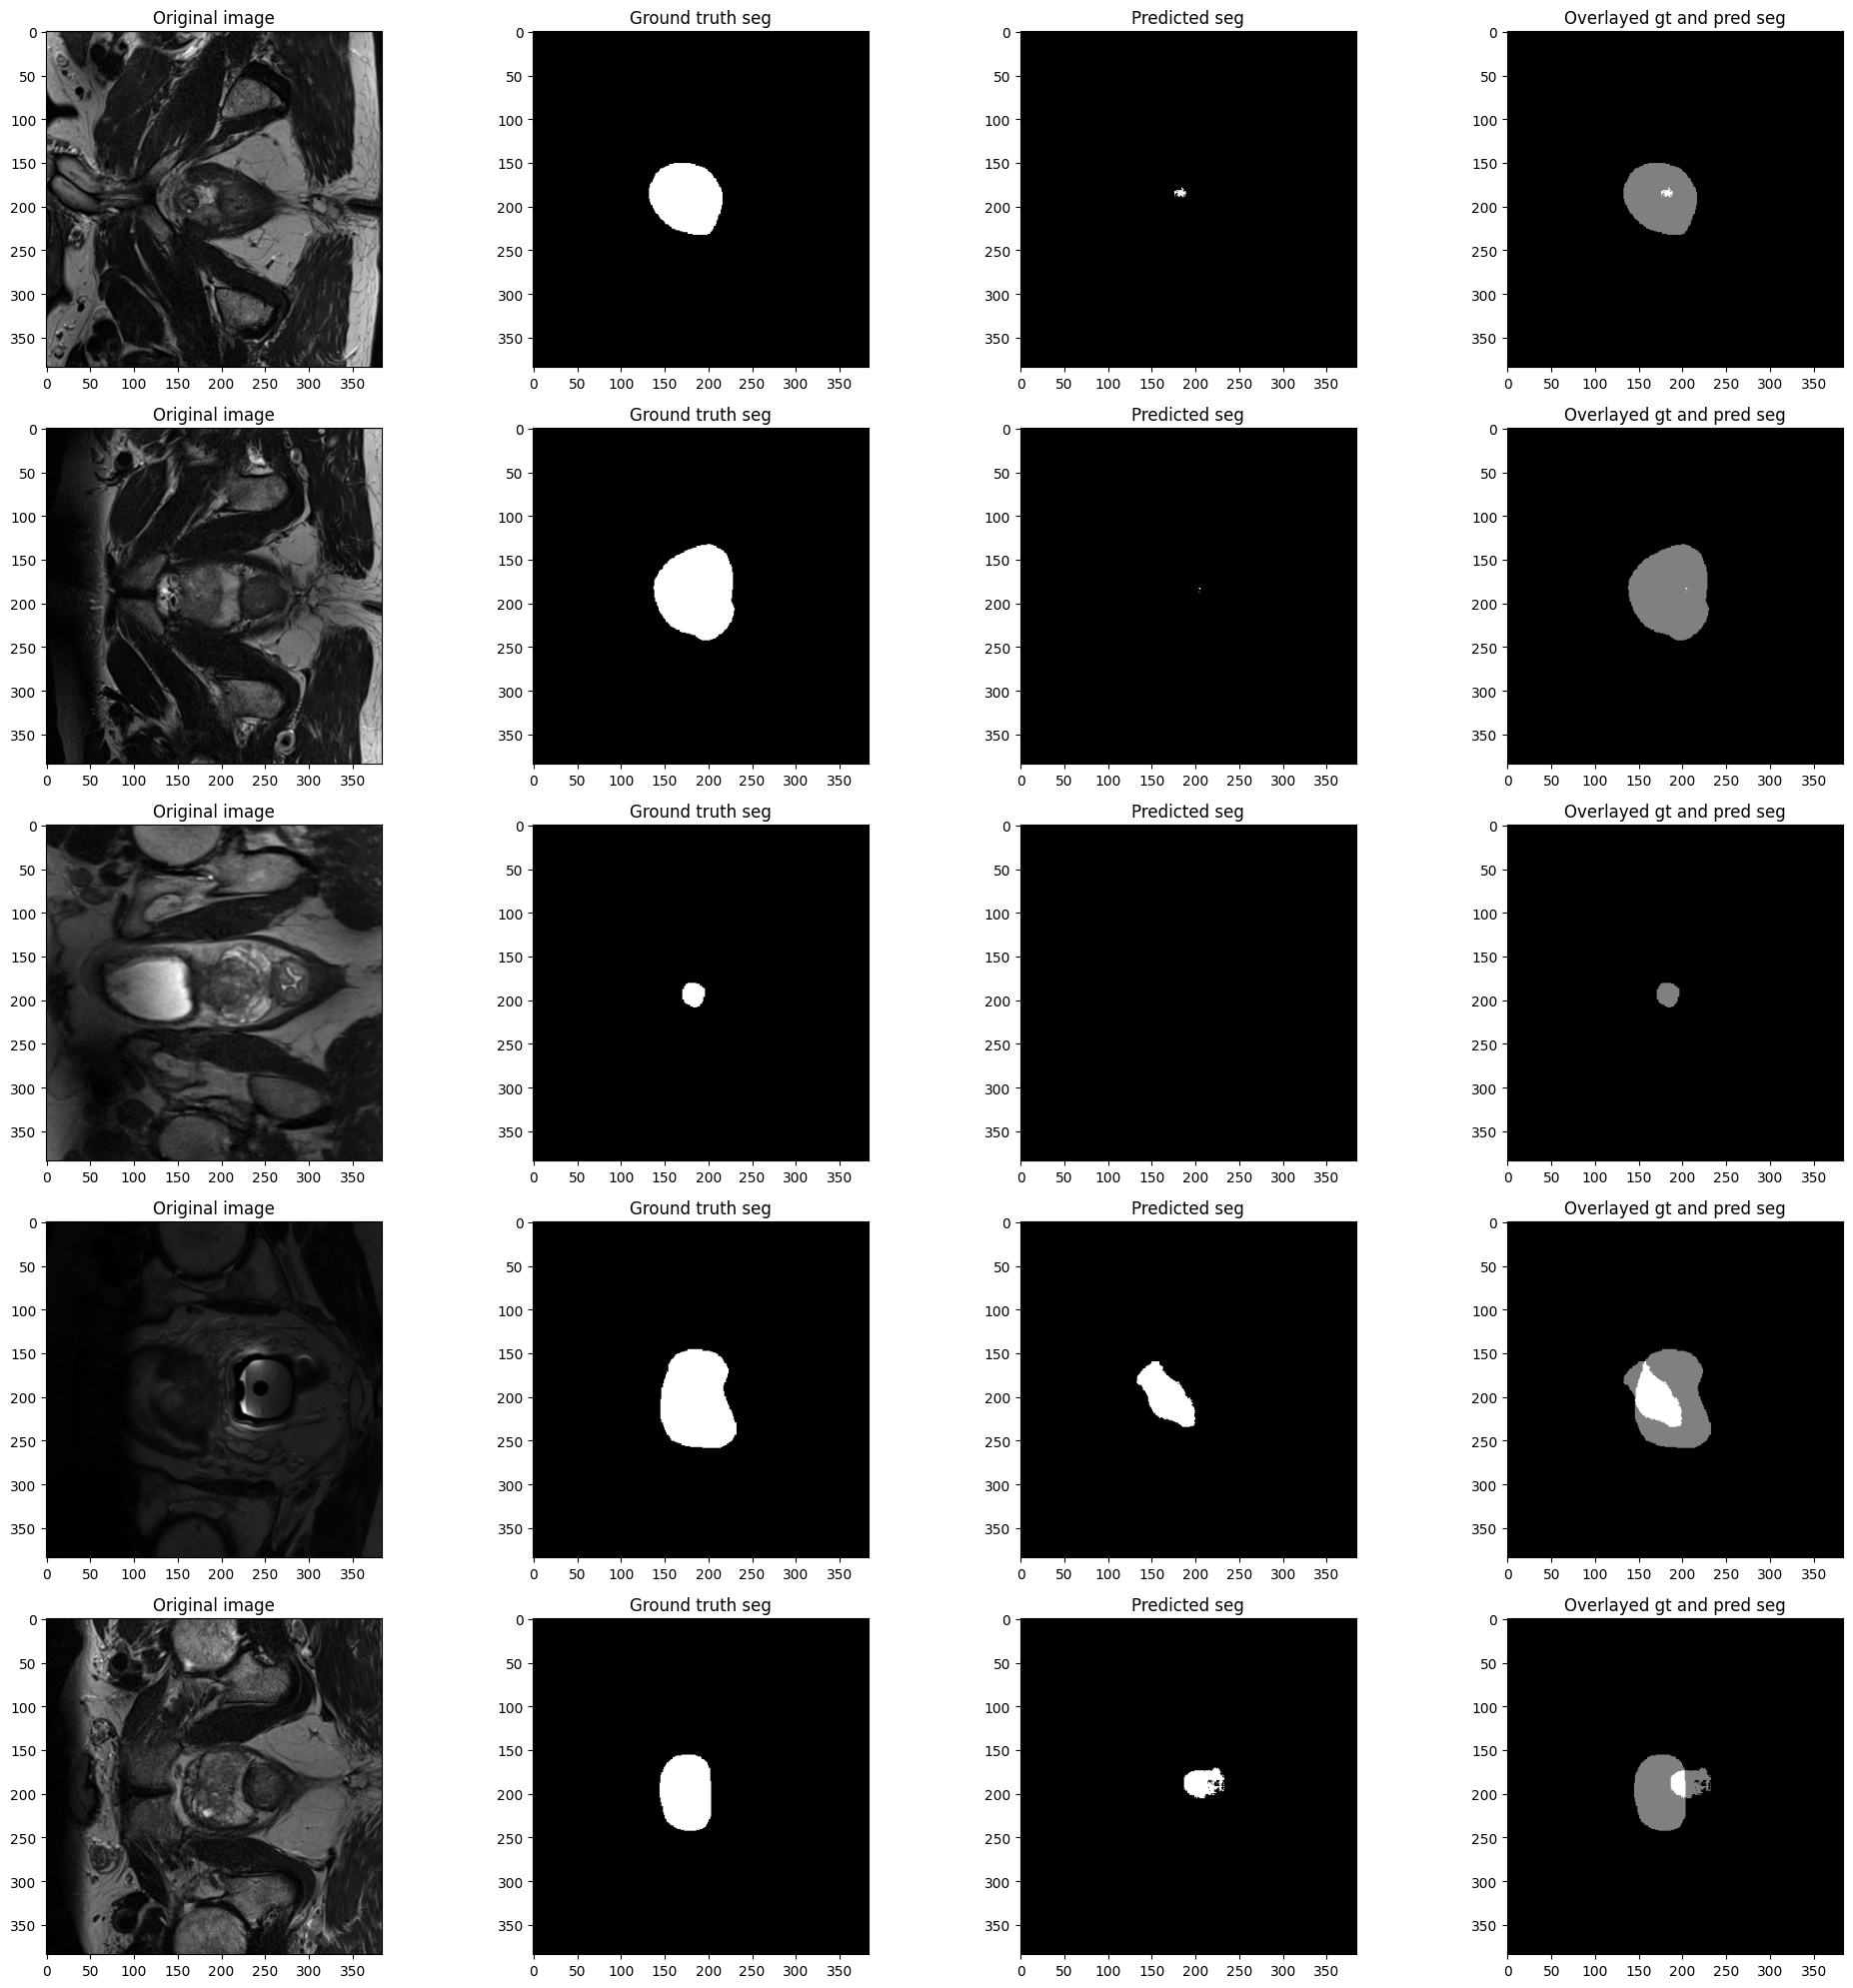

In [7]:
num_imgs = 5
indices = np.random.randint(0, len(data_valid), num_imgs)
fig, axs  = plt.subplots(num_imgs, 4, figsize=(20,20))
data = data_valid[indices]
images = data['image'].permute(3, 0, 1, 2)
labels = data['label'].permute(3, 0, 1, 2)

with torch.no_grad():
    pred = trainer.model(images.float().cuda())
    pred = torch.argmax(pred, dim = 1).detach().cpu()

for i in range(num_imgs):
    axs[i][0].set_title('Original image')
    axs[i][0].imshow(images[i].squeeze(), cmap='gray')
    axs[i][1].set_title('Ground truth seg')
    axs[i][1].imshow(labels[i].squeeze(), cmap='gray')
    axs[i][2].set_title('Predicted seg')
    axs[i][2].imshow(pred[i], cmap='gray')
    axs[i][3].set_title('Overlayed gt and pred seg')
    axs[i][3].imshow(labels[i].squeeze(), cmap='gray')
    axs[i][3].imshow(pred[i], cmap='gray', alpha=0.5)

plt.tight_layout()

#### Transforms flipd axis test

In [7]:
tr0 = Compose([
    ToTensord(keys=['image', 'label']),
    RandFlipd(keys=['image', 'label'], spatial_axis=[0], prob=1.0),
])
tr1 = Compose([
    ToTensord(keys=['image', 'label']),
    RandFlipd(keys=['image', 'label'], spatial_axis=[1], prob=1.0),
])

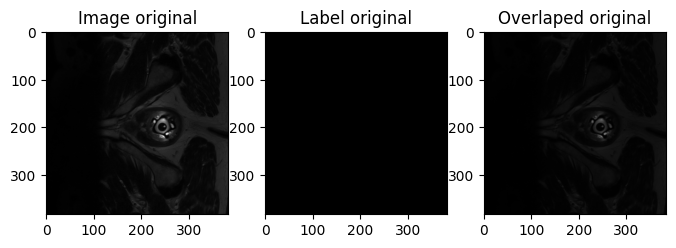

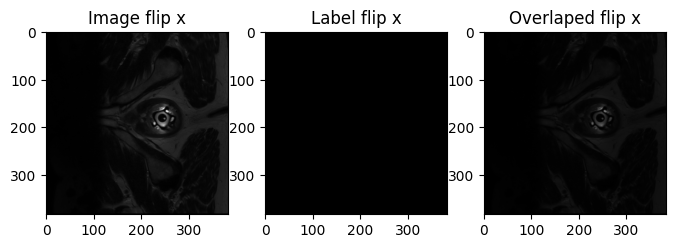

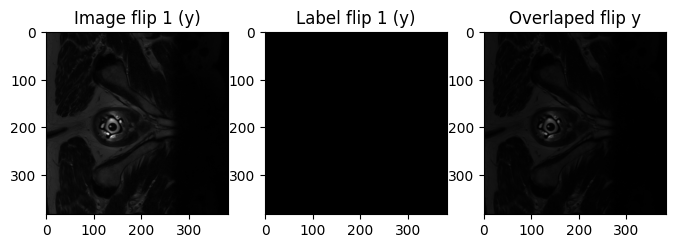

In [8]:
fig, axs = plt.subplots(1,3, figsize=(8,8))
axs[0].imshow(ds_train[0]['image'].squeeze(), cmap='gray')
axs[0].set_title('Image original')
axs[1].imshow(ds_train[0]['label'].squeeze(), cmap='gray')
axs[1].set_title('Label original')
axs[2].imshow(ds_train[0]['image'].squeeze(), cmap='gray')
axs[2].imshow(ds_train[0]['label'].squeeze(), cmap='gray', alpha=0.5)
axs[2].set_title('Overlaped original')
plt.show();
fig, axs = plt.subplots(1,3, figsize=(8,8))
tmp = tr0(ds_train[0])
axs[0].imshow(tmp['image'].squeeze(), cmap='gray')
axs[0].set_title('Image flip x')
axs[1].imshow(tmp['label'].squeeze(), cmap='gray')
axs[1].set_title('Label flip x')
axs[2].imshow(tmp['image'].squeeze(), cmap='gray')
axs[2].imshow(tmp['label'].squeeze(), cmap='gray', alpha=0.5)
axs[2].set_title('Overlaped flip x')
plt.show();
fig, axs = plt.subplots(1,3, figsize=(8,8))
tmp = tr1(ds_train[0])
axs[0].imshow(tmp['image'].squeeze(), cmap='gray')
axs[0].set_title('Image flip 1 (y)')
axs[1].imshow(tmp['label'].squeeze(), cmap='gray')
axs[1].set_title('Label flip 1 (y)')
axs[2].imshow(tmp['image'].squeeze(), cmap='gray')
axs[2].imshow(tmp['label'].squeeze(), cmap='gray', alpha=0.5)
axs[2].set_title('Overlaped flip y')
plt.show();

#### Actual test UNet

In [9]:
# transforms = Compose([
#     ToTensord(keys=['image', 'label']),
#     SpatialPadd(keys=['image', 'label'], spatial_size=ds_train._DS_CONFIG['size']),
#     RandZoomd(keys=['image', 'label'], min_zoom=0.9, max_zoom=1.2,
#               mode=('trilinear', 'nearest'), align_corners=(True, None), prob=0.15),
#     RandGaussianNoised(keys=['image'], std=0.01, prob=0.15),
#     RandGaussianSmoothd(keys=['image'], sigma_x=(0.5, 1.15),
#                         sigma_y=(0.5, 1.15), prob=0.15),
#     RandScaleIntensityd(keys=['image'], factors=0.3, prob=0.15),
#     RandFlipd(keys=['image', 'label'], spatial_axis=[0], prob=0.5),
#     RandFlipd(keys=['image', 'label'], spatial_axis=[1], prob=0.5),
#     CastToTyped(keys=['image', 'label'], dtype=(np.float32, torch.long)),
#     EnsureTyped(keys=['image', 'label'])
# ])